In [1]:
# --- IMPORT STATEMENTS ---

import numpy as np

import matplotlib.pyplot as plt

from astropy.io import fits

from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd

from photutils.detection import DAOStarFinder
from astropy.stats import sigma_clipped_stats # delete if not needed - see locate point sources cell
import healpy as hp

In [ ]:
# --- GLOBAL VARIABLES ---

LINUX_DIRECTORY = "/home/aimee/mphys"
FIGURE_SAVEDIR = "figures/masking"
SAVE_FIGS = True

GDIGS_MAPS_DIR = f"{LINUX_DIRECTORY}/data/GDIGS_moment0"
GDIGS_FNAMES = {
    "GDIGS G017.50":"GDIGS_G017.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G022.50":"GDIGS_G022.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G027.25":"GDIGS_G027.25+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G030.80":"GDIGS_G030.80+00.00_halpha_2pol_average_moment0.fits"
               }

# Get precise values! these were eyeballed
L_BOUNDS = [14.5, 32] # degrees
B_BOUNDS = [-1.5, 1.5] # degrees


In [3]:
# --- FUNCTION DEFINTIONS ---

In [4]:
# create GDIGS mosaic - from jg_notebooks/gp_plotting.ipynb

def GDIGS_mosaic():

    GDIGS_keys = list(GDIGS_FNAMES.keys())

    paths = []
    for key in GDIGS_keys:
        paths.append(f"{GDIGS_MAPS_DIR}/{GDIGS_FNAMES[key]}")

    GDIGS_rawfits = [fits.open(path)[0] for path in paths]

    mosaics = [(rawfit.data, rawfit.header) for rawfit in GDIGS_rawfits]

    mosaic_WCS, shape = find_optimal_celestial_wcs(mosaics)

    mosaic, _mosaic_ftprint = reproject_and_coadd(
        mosaics,
        output_projection = mosaic_WCS,
        shape_out = shape,
        reproject_function = reproject_interp,
        combine_function = "mean"
        )

    # prevents area outside mosaic from being plotted
    mosaic[mosaic == 0.0] = hp.UNSEEN
    # print(paths)

    return mosaic, mosaic_WCS

In [5]:
def plot_fits(fits_data, projection, x_coords=[], y_coords=[], title='Title', save_figs=SAVE_FIGS): # modified from jg_notebooks/gp_plotting.ipynb
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # convert hp.UNSEEN to np.nan for plotting

    fig, ax = plt.subplots(1, 1, figsize=(13,2), dpi=300,
                            subplot_kw={'projection':projection})

    im = ax.imshow(fits_data, origin='lower', cmap='viridis', vmin = -2, vmax = 16)
    if x_coords is not None and y_coords is not None: # optional: plot provided coordinates over image
        ax.plot(x_coords, y_coords, 'rx', markersize=3)
    
    ax.set_title(title)
    ax.set_xlabel(r"$l$ [degrees]")
    ax.set_ylabel(r"$b$ [degrees]")

    cbar = fig.colorbar(im, ax=ax, orientation='vertical')
    cbar.set_label(r"$T_b$ [K]")

    fig.subplots_adjust(left=0.07, right=0.88, top=0.95, bottom=0.05, hspace=0.4)
    plt.tight_layout()

    if SAVE_FIGS:
        plt.savefig(f"{LINUX_DIRECTORY}/{FIGURE_SAVEDIR}/{title.replace(' ', '_')}.png", dpi=300)
    
    plt.show()

In [6]:
def find_point_sources(fits_data):
    
    fits_data = np.where(fits_data == hp.UNSEEN, np.nan, fits_data) # DAOStarFinder doesn't like hp.UNSEEN

    # CHECK - what is std? of whole file or of bg? - or noise from fits file 1/file[3] for COMAP - check for GDIGS)

    # estimate mean, median, std of background
    mean, median, std = sigma_clipped_stats(fits_data, sigma=3.0) 
    # print(f'Mean bg = {mean}\nMedian bg = {median}\nStd of bg = {std}')

    # # OR calculate std of whole image
    # std = np.std(fits_data)
    # median = 0 # no bgsub
    # print(f'std of whole image: {std}')
    # print(f'Std of mosaic: {std}')

    fwhm_ps = 3 # TWEAK
    daofind =  DAOStarFinder(fwhm=fwhm_ps, threshold = 1*std) # TWEAK
    sources = daofind(fits_data - median)

    if sources:
        print(f'\nNumber of point sources identified: {len(sources)}')
        # print(sources)
        x_coords = sources['xcentroid']
        y_coords = sources['ycentroid']
    else:
        print('No point sources identified')
        x_coords = []
        y_coords = []

    return x_coords, y_coords, fwhm_ps     

In [7]:
def create_point_source_mask(fits_data, x_coords, y_coords, fwhm, show_mask=False):

    # Calculate sigma from FWHM
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))

    # Create meshgrid corresponding to image coords
    y, x = np.indices(fits_data.shape)

    # Create mask
    mask = np.zeros(fits_data.shape, dtype=bool) # empty, same shape as GDIGS mosaic
    for x_c, y_c in zip(x_coords, y_coords):
        distance = np.sqrt((x - x_c)**2 + (y - y_c)**2) 
        mask = np.logical_or(mask, distance < 3*sigma)  # if pixel is < 3*sigma away from centre of point source (i.e. inside Gaussian), mask it

    if show_mask: # quick plot, can expand to convert coords, add axis labels, etc. if necessary
        plt.imshow(mask, origin='lower', cmap='gray')
        plt.title('Point Source Mask')
        plt.show()
    
    return mask

In [8]:
def find_SNRs(file_path):
    # From D. A. Green SNR Catalogue: https://www.mrao.cam.ac.uk/surveys/snrs/snrs.data.html

    x_coords = [] # galactic coords - l
    y_coords = [] # galactic coords - b
    diameters = [] # arcmin (diameter, not radius - see documentation on website)

    with open(file_path, 'r') as file:
        for i, line in enumerate(file):
            if i > 2: # skip headers
                arr = line.split()
                # print(arr)
            
                diameter = arr[7] # either one number for both axes, or e.g. 4x6 for x and y axes
            
                # # Remove any lines w/ uncertain sizes (w/ question mark)
                # if '?' in diameter:
                #     print(f'Line {i} contains uncertain value - skipping line')
                #     continue
                
                # OR include and just strip ? from line
                diameter = diameter.replace('?', '')
            
                try: # x and y the same
                    diameter = (float(diameter), float(diameter)) 
                except ValueError: # x and y different - separated by 'x' e.g. 5x7
                    temp = diameter.split('x')
                    diameter = (float(temp[0]), float(temp[1]))
                
                diameters.append(diameter)
                x_coords.append(float(arr[0]))
                y_coords.append(float(arr[1]))

    return x_coords, y_coords, diameters

In [9]:
def convert_snr_coords(x_coords, y_coords, WCS):

    x_min, y_min = WCS.all_world2pix(float(L_BOUNDS[0]), float(B_BOUNDS[0]), 0)
    x_max, y_max = WCS.all_world2pix(float(L_BOUNDS[1]), float(B_BOUNDS[1]), 0)

    x_coords_new = []
    y_coords_new = []
    for i, _ in enumerate(x_coords):
        l = x_coords[i] 
        b = y_coords[i]
        x, y = WCS.all_world2pix(float(l), float(b), 0)

        # only append if in range
        if (x < x_min) & (x > x_max) & (y > y_min) & (y < y_max): # x inequalities flipped because axis reversed
            x_coords_new.append(x)
            y_coords_new.append(y)
    
    return x_coords_new, y_coords_new

In [10]:
def create_snr_mask(fits_data, x_coords, y_coords, diameters, show_mask=False):

    # Create meshgrid corresponding to image coords
    y, x = np.indices(fits_data.shape)

    # Create mask
    mask = np.zeros(fits_data.shape, dtype=bool) # empty, same shape as GDIGS mosaic
    for x_c, y_c, diameter_xy in zip(x_coords, y_coords, diameters):
        x_radius = diameter_xy[0]/2
        y_radius = diameter_xy[1]/2

        ellipse_condition = ((x - x_c) ** 2) / (x_radius ** 2) + ((y - y_c) ** 2) / (y_radius ** 2) <= 1
        mask = np.logical_or(mask, ellipse_condition) # if pixel within SNR ellipse, mask it
    
    if show_mask:
        plt.imshow(mask, origin='lower', cmap='gray')
        plt.title('SNR Mask')
        plt.show()

    return mask

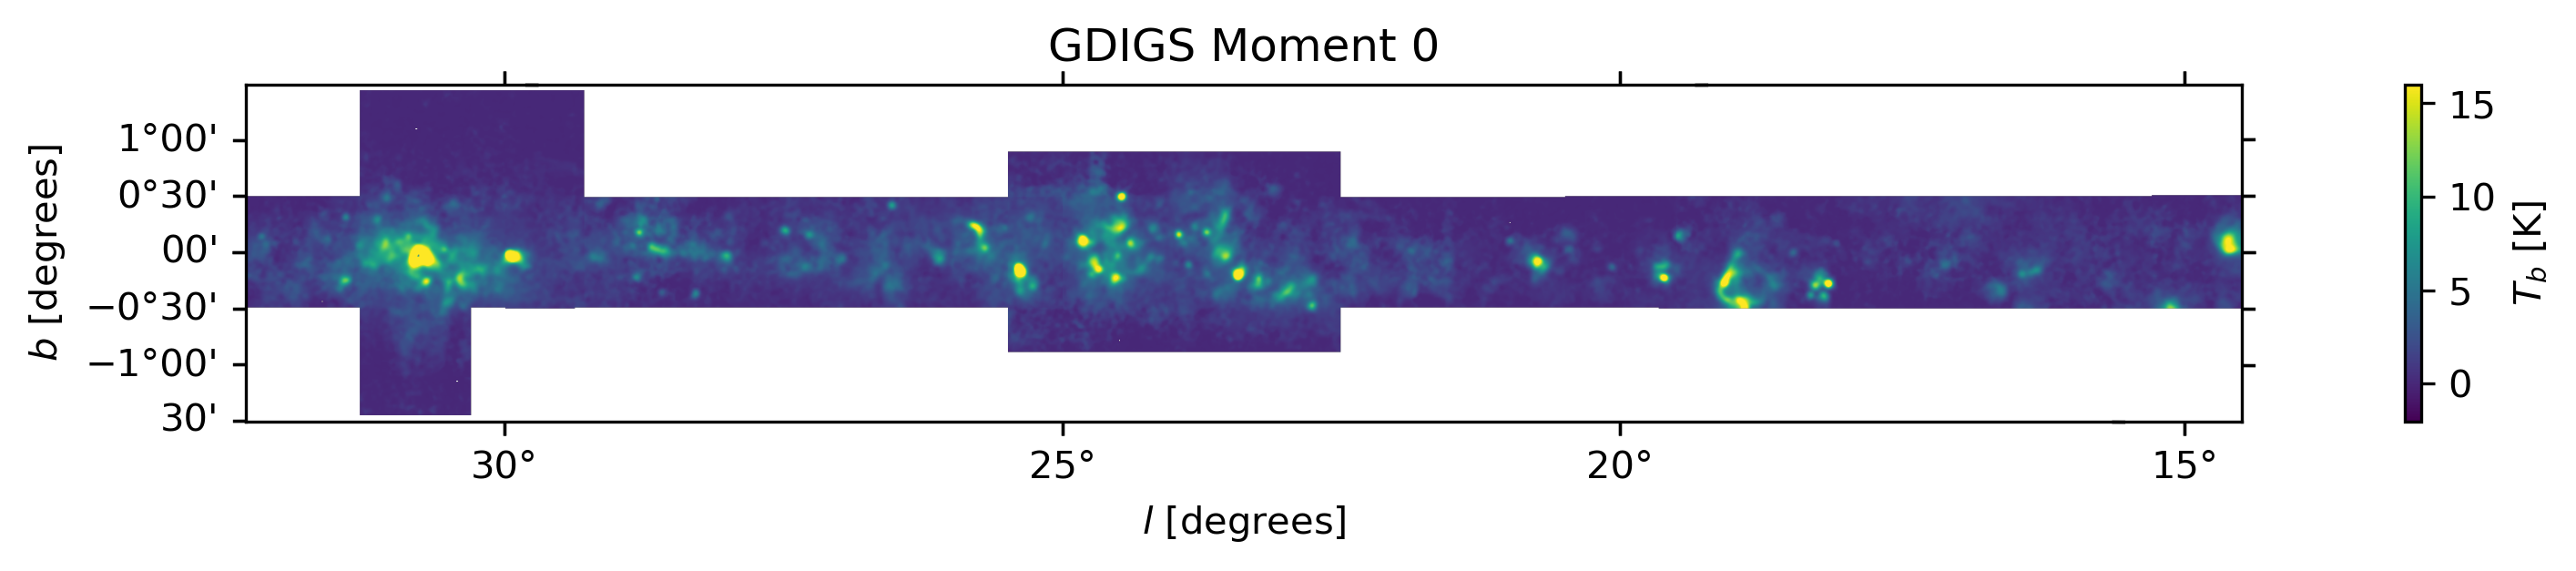


Number of point sources identified: 45


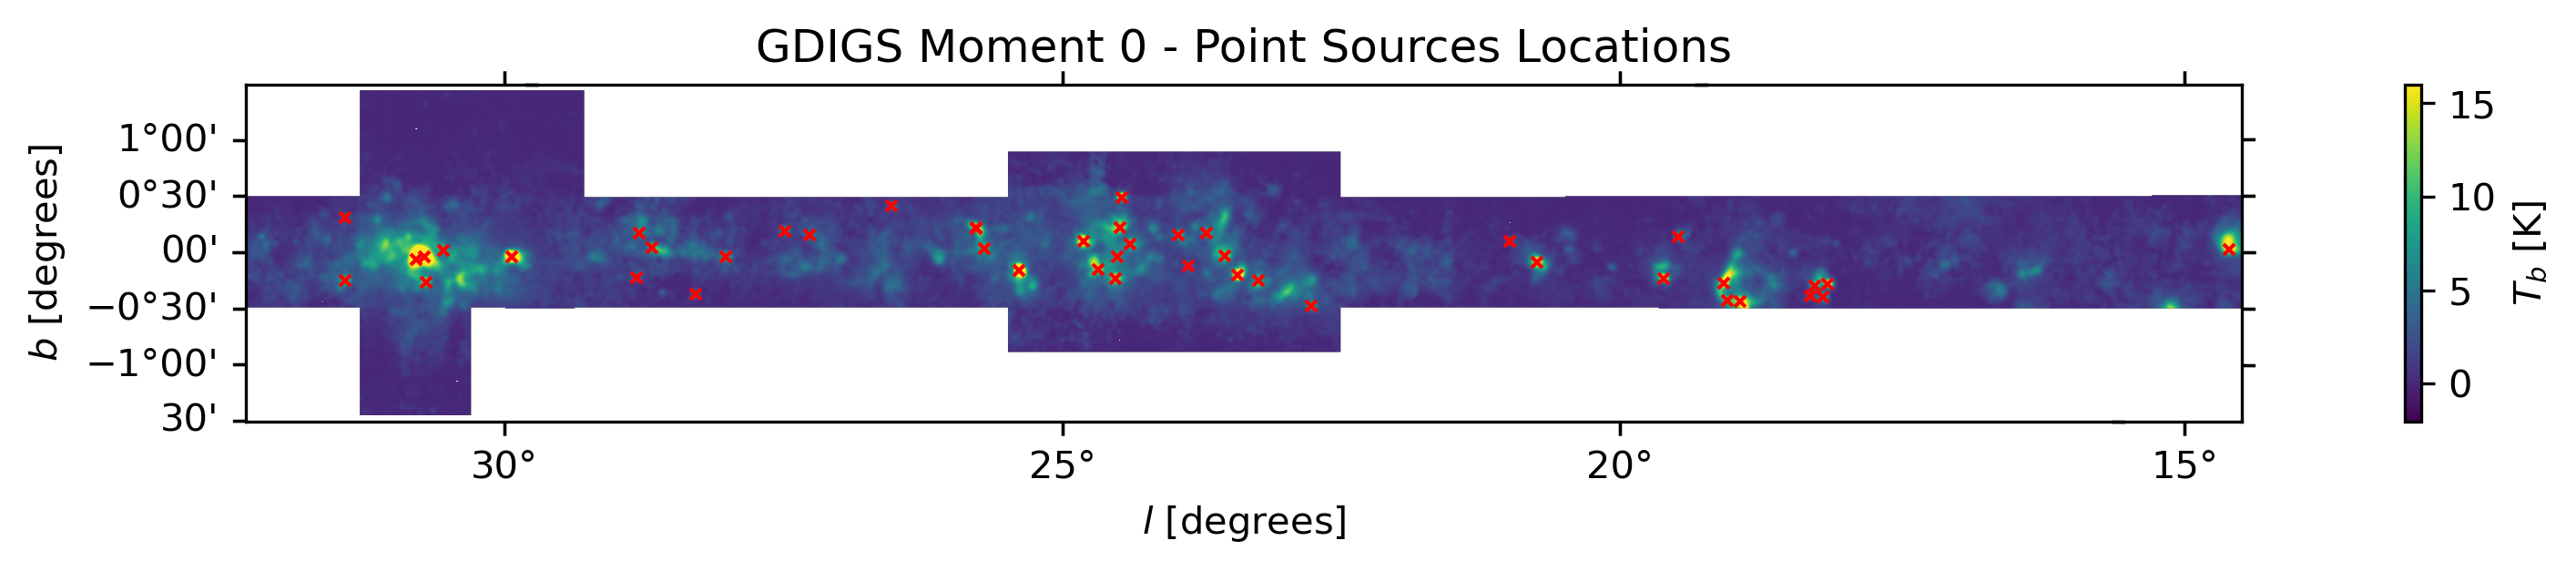

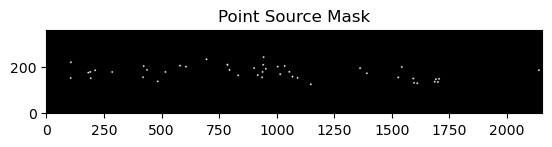

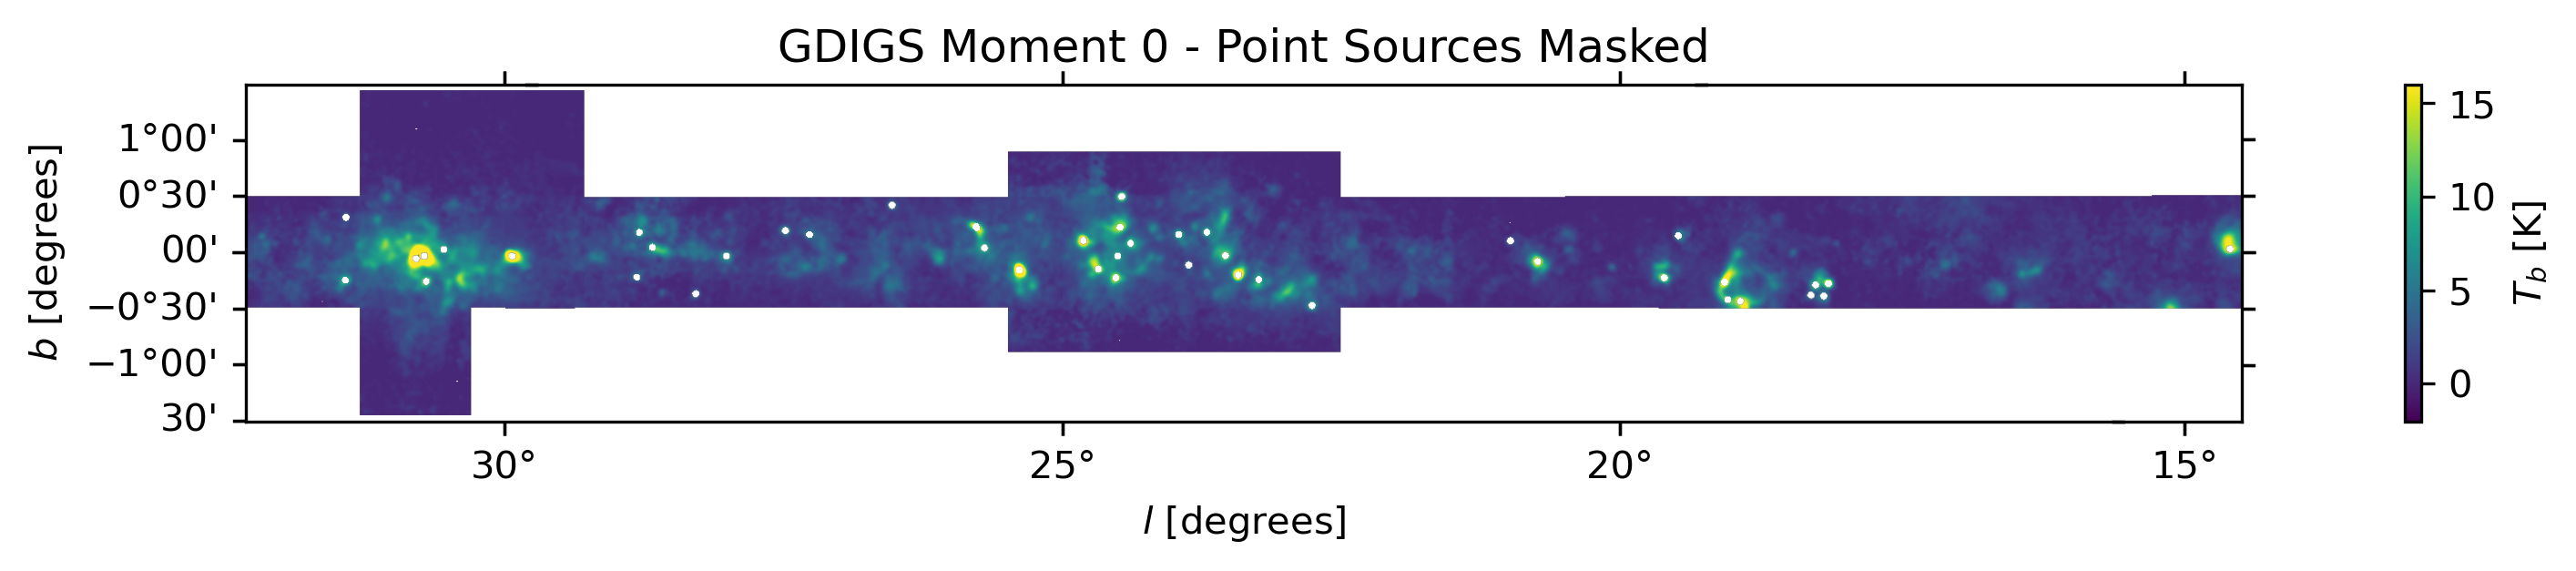

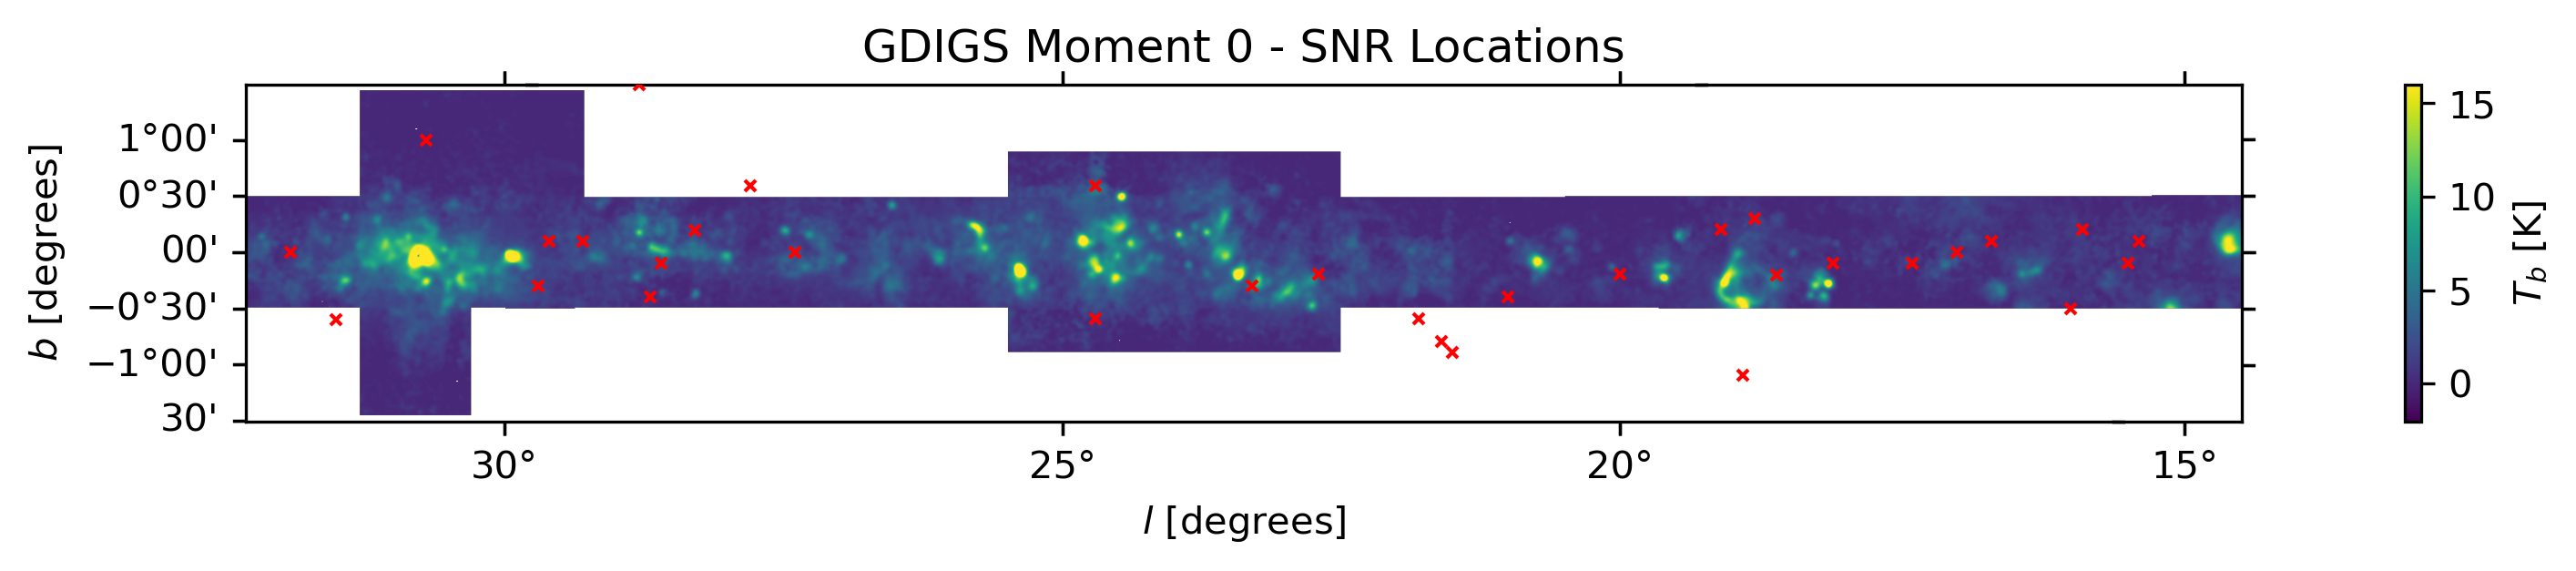

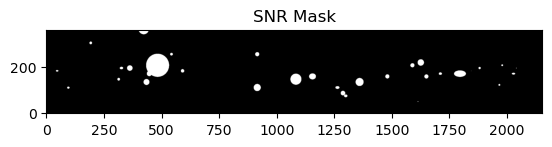

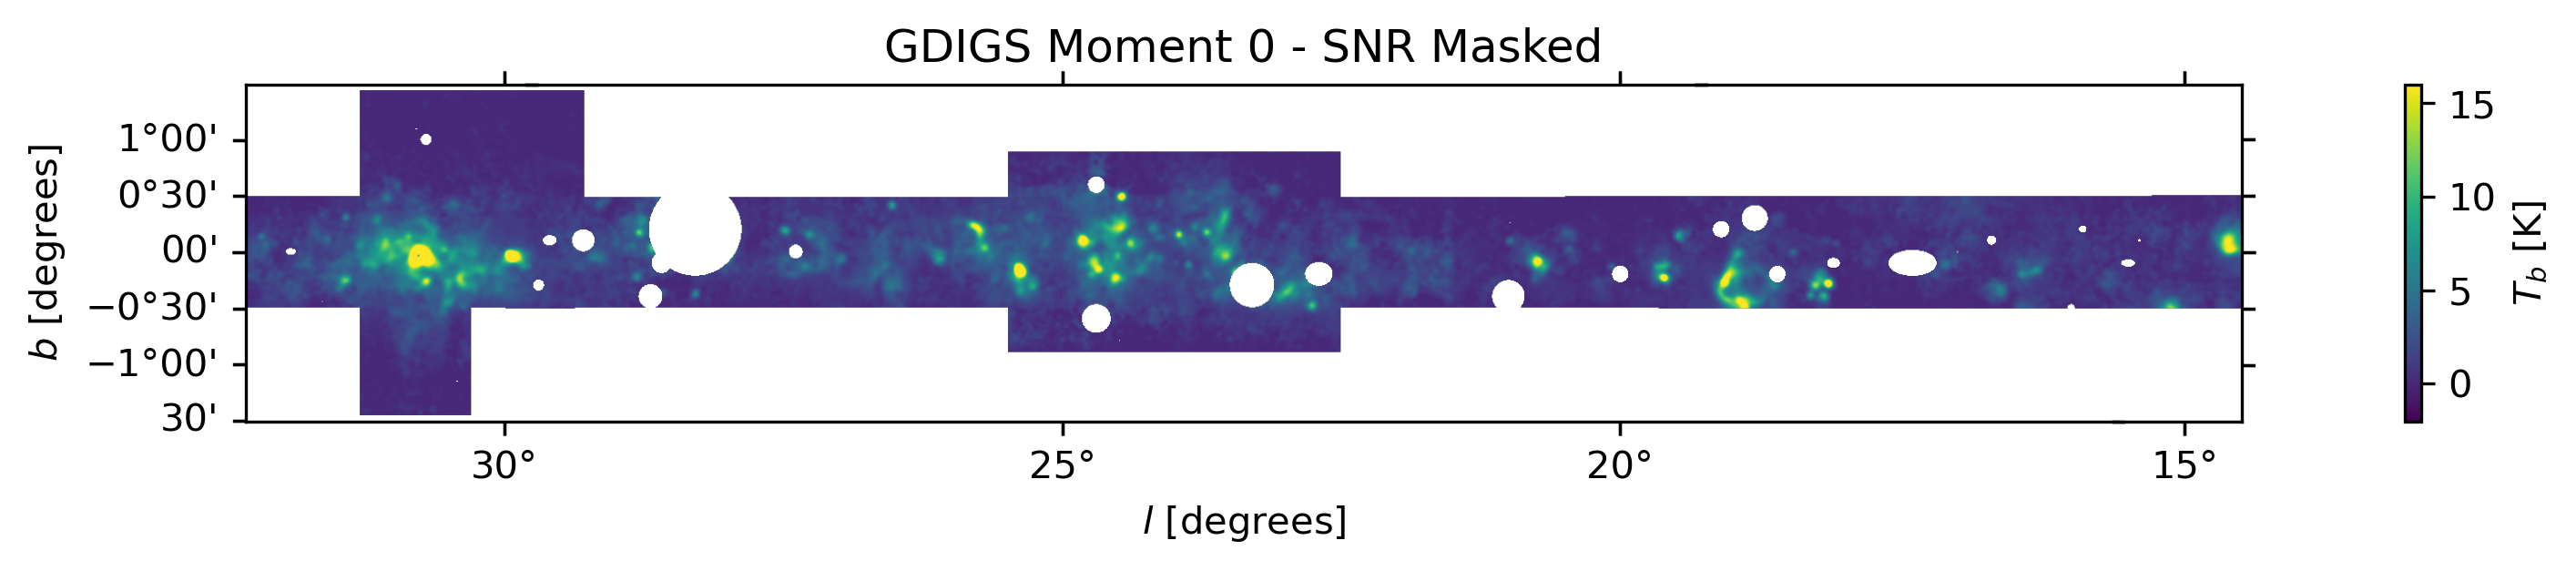

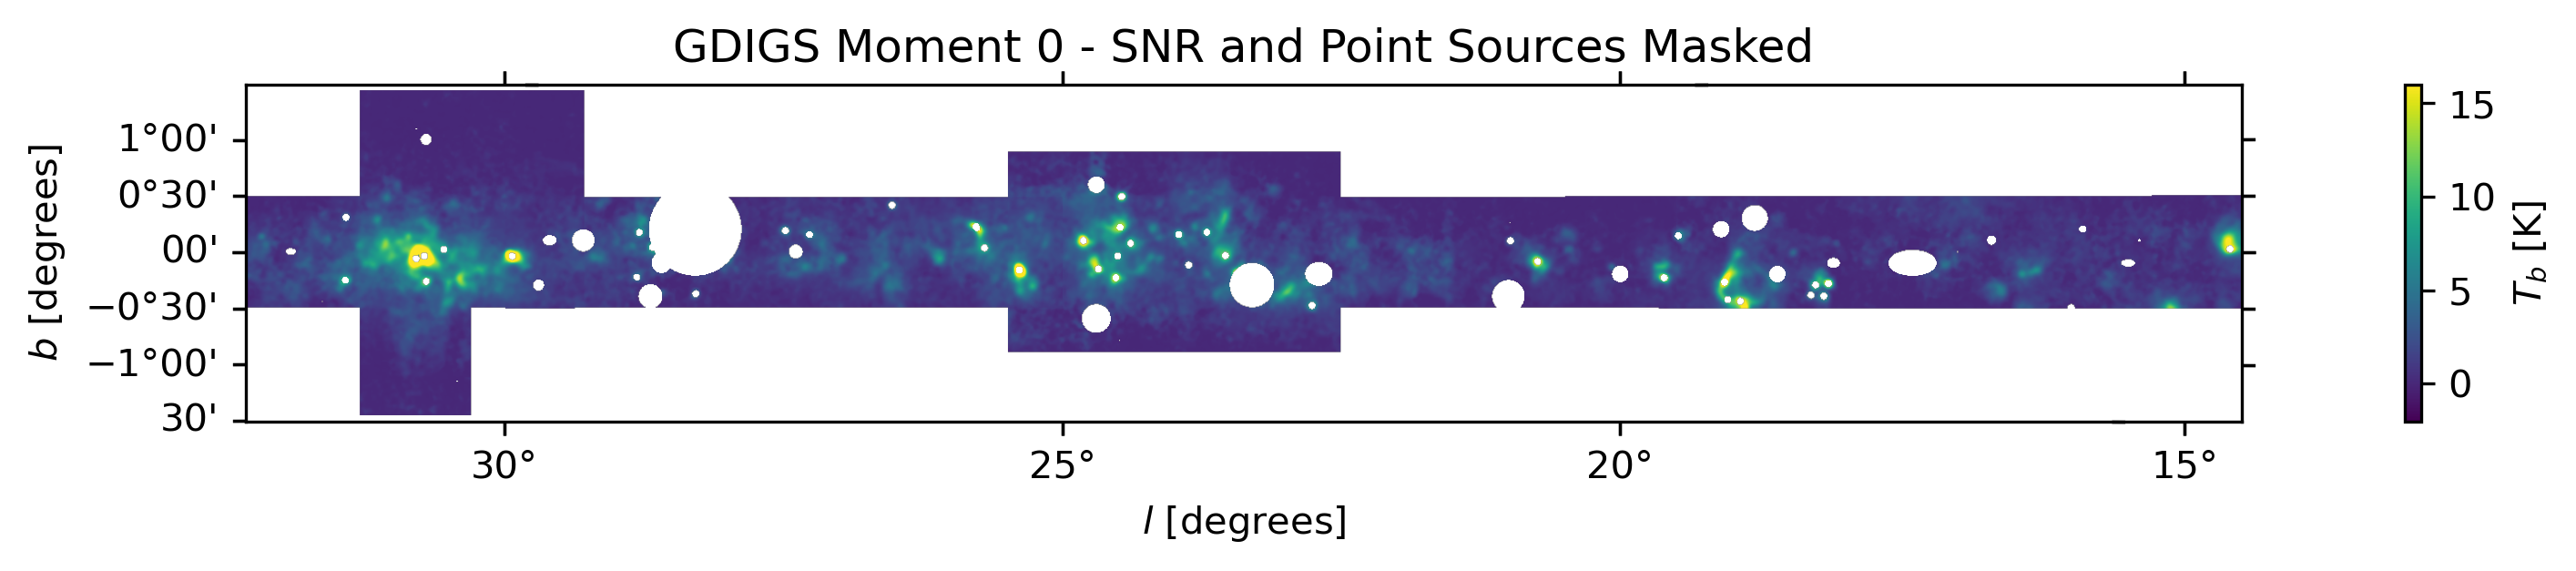

In [11]:
# --- MAIN CODE ---

# Create GDIGS mosaic
mosaic, mosaic_WCS = GDIGS_mosaic()
plot_fits(mosaic, mosaic_WCS, title='GDIGS Moment 0')

# Mask point sources
x_ps, y_ps, fwhm_ps = find_point_sources(mosaic)
plot_fits(mosaic, mosaic_WCS, x_coords=x_ps, y_coords=y_ps, title='GDIGS Moment 0 - Point Sources Locations')
mask_ps = create_point_source_mask(mosaic, x_ps, y_ps, fwhm=fwhm_ps, show_mask=True)
mosaic_ps = mosaic.copy()
mosaic_ps[mask_ps] = hp.UNSEEN
plot_fits(mosaic_ps, mosaic_WCS, title='GDIGS Moment 0 - Point Sources Masked')

# Mask supernova remnants
x_snr, y_snr, diameters = find_SNRs(file_path=f'{LINUX_DIRECTORY}/data/SNR_Catalogue_DAGreen.txt')
x_snr, y_snr = convert_snr_coords(x_snr, y_snr, mosaic_WCS)
plot_fits(mosaic, mosaic_WCS, x_coords=x_snr, y_coords=y_snr, title='GDIGS Moment 0 - SNR Locations')
mask_snr = create_snr_mask(mosaic, x_snr, y_snr, diameters, show_mask=True)
mosaic_snr = mosaic.copy()
mosaic_snr[mask_snr] = hp.UNSEEN
plot_fits(mosaic_snr, mosaic_WCS, title='GDIGS Moment 0 - SNR Masked')

# Apply both masks
mosaic_ps_snr = mosaic.copy()
mosaic_ps_snr[mask_snr] = hp.UNSEEN
mosaic_ps_snr[mask_ps] = hp.UNSEEN
plot_fits(mosaic_ps_snr, mosaic_WCS, title='GDIGS Moment 0 - SNR and Point Sources Masked')